<h1>This is the primary notebook for the generative pre-trained transformer.</h1>
<br>
This file contains our cleaned, revised work, and experimental or older code should be put elsewhere

**Authors:** Jesan Ahammed Ovi, Stone Amsbaugh

**Instructor:** Michael Ivanitsky

In [3]:
#get the necessary imports and define our config class
from dataclasses import dataclass
import torch
import torch.nn as nn
import numpy as np
import requests
import re
import matplotlib.pyplot as plt

#our custom utility files
from vocab_utility import get_token_arr, get_dictionaries
#from recipe_utility import *

@dataclass
class Config:
    d_model:int
    d_vocab:int
    d_hidden:int
    max_seq_len:int
    n_transformers:int

In [4]:
#this cell defines our MLP, Attention head, transformer that combines these, as well as the language model containing these

#Multi layer perceptron module, just a NN
class MLP(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.fc1 = nn.Linear(config.d_model, config.d_hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(config.d_hidden, config.d_model)

    def forward(self, x):
        x = self.fc2(self.act(self.fc1(x)))
        return x
    
#'secret sauce' attention head. Allows the model to look back at previous tokens indefinitely, and select what is important
class Attention(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        #initialize our parameters to be random
        self.Wqk = nn.Parameter(torch.rand(config.d_model, config.d_model))
        self.Wov = nn.Parameter(torch.rand(config.d_model, config.d_model))

        #create the mask, which isn't a model parameter but we still need it
        mask = torch.triu(torch.ones(config.max_seq_len, config.max_seq_len), diagonal=1)
        mask = mask.masked_fill(mask==1, -float('inf'))
        self.register_buffer("M", mask)

    
    def forward(self, x): 
        T = x.size(0)
        temp = x @ self.Wqk @ x.T + self.M[:T, :T]
        scores = torch.softmax(temp,dim=-1)
        scores = scores @ x @ self.Wov

        return scores
    
class Transformer(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.attn = Attention(config)
        self.mlp = MLP(config)
        self.mlp_normalizer = nn.LayerNorm(config.d_model)
        self.attn_normalizer = nn.LayerNorm(config.d_model)

    def forward(self, x):
        attn_out = self.attn(self.attn_normalizer(x))
        mlp_out = self.mlp(self.mlp_normalizer(x))

        return x+attn_out+mlp_out
    
#compile multiple transformers, embedding layer, and our output layer, as well as our overall configurations into the language model
class LanguageModel(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(self.config.d_vocab, self.config.d_model)
        self.tbs = nn.ModuleList([Transformer(self.config) for _ in range(self.config.n_transformers)])
        self.lm_head = nn.Linear(self.config.d_model, self.config.d_vocab)
    
    def forward(self, x_tokens):
        temp = self.embedding(x_tokens)
        #look that propagates this through the transformer layers
        for i in range(self.config.n_transformers):
            temp = self.tbs[i](temp)

        logits = self.lm_head(temp)
        
        return logits

Now we have our architecture built out, we will implement a training loop. This first demonstration will be on the Gutenberg sample

In [5]:
#Some utility functions for processing vocabulary
def get_dictionaries(tokens):
    # takes array of words(tokens), makes forward and backward dictionaries from words to their token identifiers
    forward_dict = {} #get token ID
    backward_dict = {} #get english token
    i = 0
    for token in tokens:
        if token in forward_dict:
            continue
        #if new token, give it an ID
        forward_dict[token] = i
        backward_dict[i] = token
        i+=1
    
    return forward_dict, backward_dict

def get_token_arr(text):
    #return(["A"])
    #takes text and makes more standardized tokens
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\.? \n]', '', text)
    #add a space to make the punctuation their own tokens
    text.replace("."," .")
    text.replace(","," ,")
    text.replace("?"," ?")
    text.replace("!"," !")
    
    token_arr = text.split()
    return token_arr

In [5]:
# Demo 1 - Gutenberg - gather text
url = "https://www.gutenberg.org/files/1342/1342-0.txt" 
r = requests.get(url)

In [6]:
# make tokens, token IDs
tokens = get_token_arr(r.text) # TODO: Find a better way to tokenize this. Michael suggested we treat standard punctuation as their own tokens, split on whitespace, and drop other characters

token_to_id, id_to_token = get_dictionaries(tokens) #get unique IDs for all the tokens
d_vocab = len(token_to_id)

config = Config(d_model=64, d_vocab=d_vocab, d_hidden=128, max_seq_len=1024, n_transformers=2)  

token_ids = [token_to_id[tok] for tok in tokens]

In [18]:
### Training Loop ###

N = 1000 #number of training steps

#for plotting:
losses = [-1 for _ in range(N)]

model = LanguageModel(config)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for step in range(N):  # number of training steps
    # sample a random chunk of text
    start = np.random.randint(0, len(token_ids) - config.max_seq_len - 1)
    x_ids = torch.tensor(token_ids[start:start+config.max_seq_len])
    y_ids = torch.tensor(token_ids[start+1:start+config.max_seq_len+1])
    logits = model(x_ids)
    targets = y_ids
    loss = loss_fn(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[step] = loss.item()

    if step % 50 == 0:
        print(f"step {step}, loss = {loss.item():.4f}")


step 0, loss = 10.8802
step 50, loss = 7.8089
step 100, loss = 6.8042
step 150, loss = 6.7516
step 200, loss = 5.9302
step 250, loss = 6.2216
step 300, loss = 6.0927
step 350, loss = 6.0341
step 400, loss = 5.7629
step 450, loss = 5.7529
step 500, loss = 5.6887
step 550, loss = 5.3437
step 600, loss = 5.6745
step 650, loss = 5.5869
step 700, loss = 5.2183
step 750, loss = 5.2422
step 800, loss = 5.4800
step 850, loss = 5.9738
step 900, loss = 5.2278
step 950, loss = 5.0627


1230011


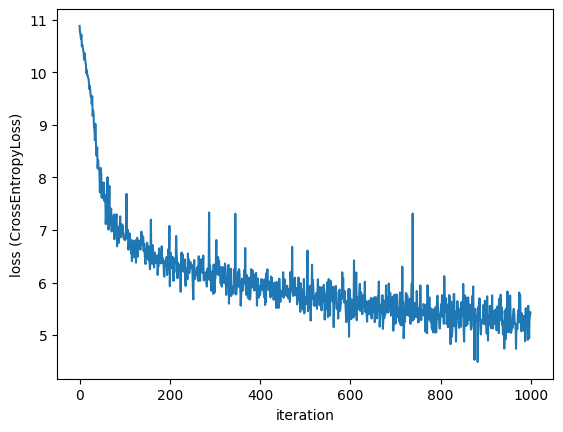

In [23]:

print(sum(p.numel() for p in model.parameters()))
#plot the loss
plt.plot(list(range(N)),losses)
plt.xlabel('iteration')
plt.ylabel('loss (CrossEntropyLoss)')
plt.show()

In [ ]:
max_num_tokens = 20
prompt_text = ""

for i in range(max_num_tokens):
    prompt_tokens = [token_to_id[tok] for tok in prompt_text.lower().split()]
    prompt_tensor = torch.tensor(prompt_tokens)

    with torch.no_grad():
        logits = model(prompt_tensor)
    
    last_logits = logits[-1]
    prob = torch.softmax(last_logits, dim=-1)
    next_token_id = torch.argmax(prob).item()
    next_token = id_to_token[next_token_id]
    print(next_token, end=' ')

    # append to prompt
    prompt_text += " " + next_token

and the first to the same to the very different and to the other to the other to the other 

In [ ]:
# save the model
torch.save(model.state_dict(),'models/gutenberg_model.mdl')

Now train this on our recipes dataset

In [6]:
# get the recipe dataset
with open('texts/recipes.txt','r',encoding='utf8') as f:
    text = f.read()

In [7]:
# make tokens, token IDs
tokens = get_token_arr(text) # Find a better way to tokenize this. Michael suggested we treat standard punctuation as their own tokens, split on whitespace, and drop other characters

token_to_id, id_to_token = get_dictionaries(tokens) #get unique IDs for all the tokens
d_vocab = len(token_to_id)

config = Config(d_model=64, d_vocab=d_vocab, d_hidden=128, max_seq_len=1024, n_transformers=2)  

token_ids = [token_to_id[tok] for tok in tokens]

In [8]:
### Training Loop ###

N = 1000 #number of training steps

#for plotting:
losses = [-1 for _ in range(N)]

model = LanguageModel(config)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for step in range(N):  # number of training steps
    # sample a random chunk of text
    start = np.random.randint(0, len(token_ids) - config.max_seq_len - 1)
    x_ids = torch.tensor(token_ids[start:start+config.max_seq_len])
    y_ids = torch.tensor(token_ids[start+1:start+config.max_seq_len+1])
    logits = model(x_ids)
    targets = y_ids
    loss = loss_fn(logits, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[step] = loss.item()

    if step % 50 == 0:
        print(f"step {step}, loss = {loss.item():.4f}")

step 0, loss = 11.9418
step 50, loss = 8.0269
step 100, loss = 7.2727
step 150, loss = 6.4161
step 200, loss = 6.6795
step 250, loss = 6.1232
step 300, loss = 6.0056
step 350, loss = 5.5519
step 400, loss = 5.8575
step 450, loss = 5.6343
step 500, loss = 6.0211
step 550, loss = 6.1382
step 600, loss = 5.9963
step 650, loss = 5.1409
step 700, loss = 5.1857
step 750, loss = 4.8794
step 800, loss = 5.4310
step 850, loss = 5.1480
step 900, loss = 5.0412
step 950, loss = 5.4502


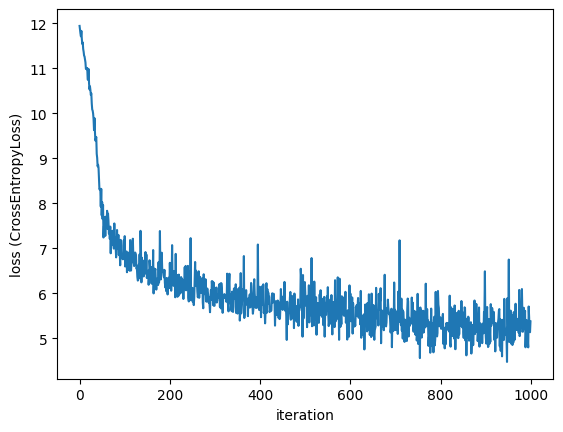

In [9]:
#plot the loss
plt.plot(list(range(N)),losses)
plt.xlabel('iteration')
plt.ylabel('loss (CrossEntropyLoss)')
plt.show()

In [10]:
# save the model
torch.save(model.state_dict(), 'models/recipe_model.mdl')

In [11]:
# from scratch - load the tokens and then load the model
with open('texts/recipes.txt','r',encoding='utf8') as f:
    text = f.read()

tokens = get_token_arr(text) # TODO: Find a better way to tokenize this. Michael suggested we treat standard punctuation as their own tokens, split on whitespace, and drop other characters

token_to_id, id_to_token = get_dictionaries(tokens) #get unique IDs for all the tokens
d_vocab = len(token_to_id)

config = Config(d_model=64, d_vocab=d_vocab, d_hidden=128, max_seq_len=1024, n_transformers=2)  

token_ids = [token_to_id[tok] for tok in tokens]

model = LanguageModel(config)
model.load_state_dict(torch.load('models/recipe_model.mdl'))

<All keys matched successfully>

In [12]:
# query the model by adjusting expected output tokens and prompt
max_num_tokens = 20
prompt_text = "how to make a salad"

for i in range(max_num_tokens):
    prompt_tokens = [token_to_id[tok] for tok in prompt_text.lower().split()]
    prompt_tensor = torch.tensor(prompt_tokens)

    with torch.no_grad():
        logits = model(prompt_tensor)
    
    last_logits = logits[-1]
    prob = torch.softmax(last_logits, dim=-1)
    #next_token_id = torch.argmax(prob).item()
    next_token_id = torch.multinomial(prob, num_samples=1).item()
    next_token = id_to_token[next_token_id]
    print(next_token, end=' ')

    # append to prompt
    prompt_text += " " + next_token

and assemble into pieces slightly eggs and seitan sit and egg the eggs 2 hours ahead. away of other the 

<h2 style="font-size:25px">Challenges Faced During GPT Implementation</h2>

<ul>
  <li>One of the primary challenges we faced during the implementation was deciding <b>where to begin the coding process</b>. Initially, we started with input preprocessing tasks such as text cleaning, tokenization, and embedding. However, this approach made it difficult to understand how the processed inputs would eventually flow into the Transformer architecture. As a result, we struggled to connect early-stage components with the attention and Transformer layers. With guidance from the course instructor, we adopted a more structured, bottom-up approach: first implementing a simple MLP, then building the attention mechanism, followed by the Transformer layer, and finally integrating everything into a unified LanguageModel class. Only after this structural foundation was complete did we focus on input processing, training loops, and text generation. This change in strategy resolved much of our confusion and led to significant progress, ultimately allowing us to complete 
  the project successfully.</li>

  <br>

  <li>Another major challenge arose while <b>implementing the self-attention mechanism</b>, particularly in handling the dimensions of the attention mask matrix (<i>commonly referred to as the M matrix</i>). Since the shape of the input tensor X can vary between training and inference—especially with different sequence lengths—it was nontrivial to ensure that the mask matrix always had compatible dimensions. Several runtime errors and incorrect attention behaviors stemmed from this issue, requiring careful reasoning about tensor shapes and broadcasting rules.</li>

  <br>

  <li>A further difficulty we encountered was related to <b>training stability</b>. At the beginning of training, the loss values were extremely large (on the order of six digits), even though they decreased steadily with each iteration. While this behavior initially seemed alarming, we later addressed it by incorporating a normalization layer within the Transformer architecture. Normalization helped stabilize the activations by transforming arbitrarily large or small values into a more well-behaved distribution, which significantly improved training dynamics and overall model performance.</li>
  
</ul>